# Cafe Sales - Location Prediction (Classification)

Predicts whether a transaction was **In-store** or **Takeaway** from `Quantity`, `Price Per Unit`, and the encoded `Item`.

## 1. Load & Clean Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

df = pd.read_csv('D&S_cafe.csv.csv')          # <-- put the CSV in the same folder
print("Raw shape:", df.shape)

# Drop rows with no target label, fill missing feature values
df = df.dropna(subset=['Location']).copy()
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
print("Clean shape:", df.shape)

Raw shape: (10000, 8)
Clean shape: (6039, 8)

## 2. Encode categorical columns

In [ ]:
item_le = LabelEncoder()
df['Item_encoded'] = item_le.fit_transform(df['Item'])

loc_le = LabelEncoder()
df['Location_encoded'] = loc_le.fit_transform(df['Location'])   # In-store=0, Takeaway=1
print("Location classes:", list(loc_le.classes_))

features = ['Quantity', 'Price Per Unit', 'Item_encoded']
X = df[features]
y = df['Location_encoded']

Location classes: ['In-store', 'Takeaway']

## 3. SelectKBest feature scores

In [ ]:
skb = SelectKBest(score_func=f_classif, k='all')
skb.fit(X, y)
skb_scores = pd.Series(skb.scores_, index=features).sort_values(ascending=False)
skb_scores

Price Per Unit    3.663805
Item_encoded      2.308018
Quantity          0.041214
dtype: float64

## 4. Train / test split & model training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
}

results = {}
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Recall": recall_score(y_test, preds)
    }
    fitted[name] = model

results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
results_df

                     Accuracy    Recall
Decision Tree        0.523179  0.507438
Random Forest        0.514073  0.514050
Logistic Regression  0.506623  0.517355
KNN                  0.504139  0.540496
Naive Bayes          0.495861  0.489256

## 5. Best model by each metric

In [ ]:
best_acc_model = results_df['Accuracy'].idxmax()
best_rec_model = results_df['Recall'].idxmax()
print(f"Best Model by Accuracy: {best_acc_model}")
print(f"Best Model by Recall: {best_rec_model}")

Best Model by Accuracy: Decision Tree
Best Model by Recall: KNN

## 6. Random Forest feature importance

In [ ]:
rf_importance = pd.Series(fitted["Random Forest"].feature_importances_, index=features).sort_values(ascending=False)
rf_importance

Quantity          0.377368
Item_encoded      0.373505
Price Per Unit    0.249127
dtype: float64

## 7. Model comparison charts

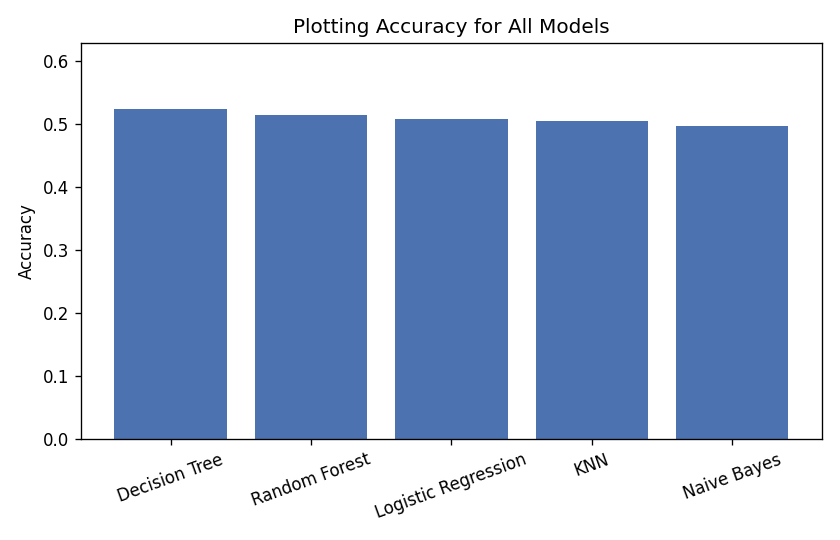

In [ ]:
plt.figure(figsize=(7,4.5))
plt.bar(results_df.index, results_df['Accuracy'], color='#4C72B0')
plt.ylabel('Accuracy'); plt.title('Accuracy by Model'); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

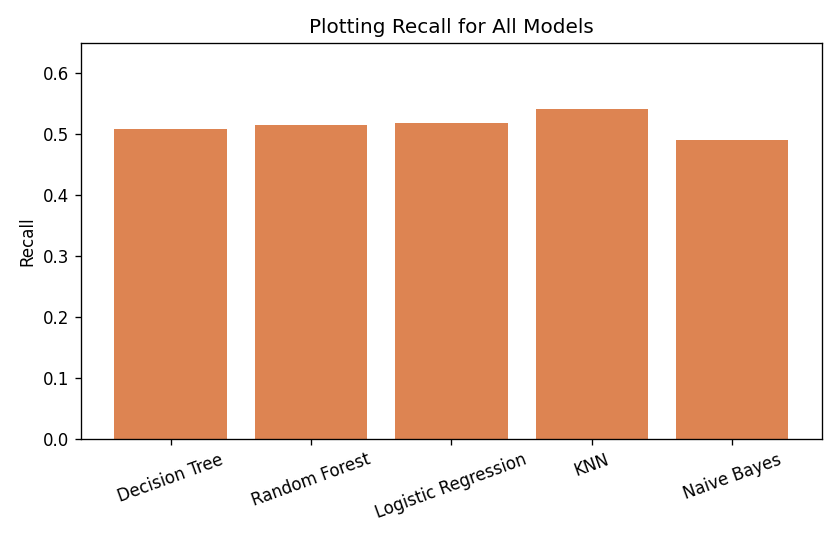

In [ ]:
plt.figure(figsize=(7,4.5))
plt.bar(results_df.index, results_df['Recall'], color='#DD8452')
plt.ylabel('Recall'); plt.title('Recall by Model'); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

### KNN vs Random Forest, side by side

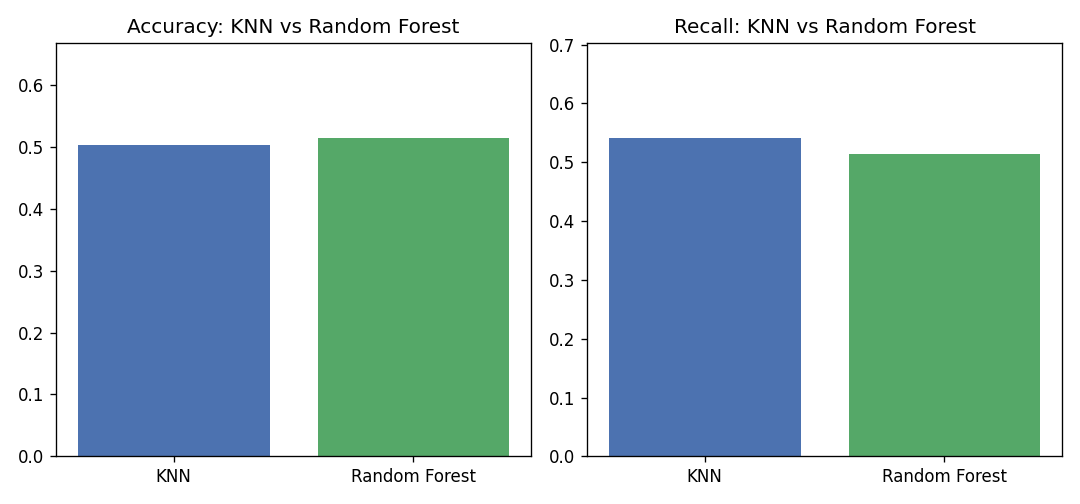

Random Forest Accuracy is 0.99 pct points higher than KNN's Accuracy.
KNN Recall is 2.64 pct points higher than Random Forest's Recall.

In [ ]:
sub = results_df.loc[['KNN','Random Forest']]
fig, axes = plt.subplots(1, 2, figsize=(9,4.2))
axes[0].bar(sub.index, sub['Accuracy'], color=['#4C72B0','#55A868']); axes[0].set_title('Accuracy: KNN vs RF')
axes[1].bar(sub.index, sub['Recall'], color=['#4C72B0','#55A868']); axes[1].set_title('Recall: KNN vs RF')
plt.tight_layout(); plt.show()

rf_acc, knn_acc = results_df.loc["Random Forest","Accuracy"], results_df.loc["KNN","Accuracy"]
rf_rec, knn_rec = results_df.loc["Random Forest","Recall"], results_df.loc["KNN","Recall"]
print(f"Random Forest Accuracy is {(rf_acc-knn_acc)*100:.2f} pct points higher than KNN's Accuracy.")
print(f"KNN Recall is {(knn_rec-rf_rec)*100:.2f} pct points higher than Random Forest's Recall.")

## 8. Confusion matrix - KNN

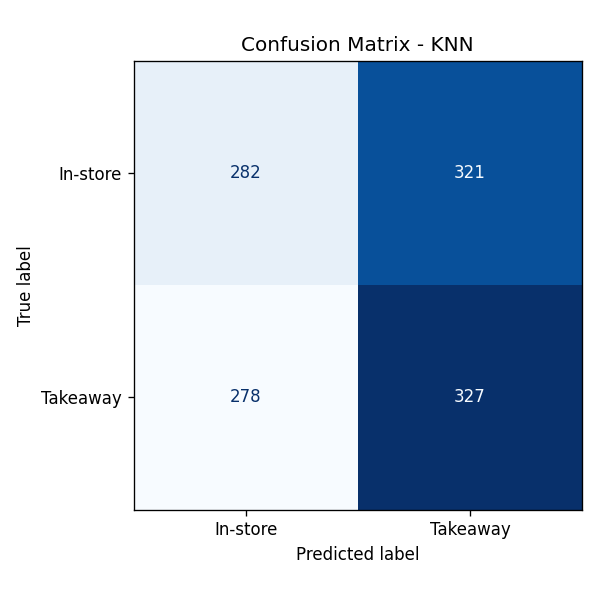

In [ ]:
knn_preds = fitted['KNN'].predict(X_test)
cm = confusion_matrix(y_test, knn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=loc_le.classes_)
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - KNN')
plt.tight_layout(); plt.show()

## 9. Permutation importance - KNN

In [ ]:
perm = permutation_importance(fitted["KNN"], X_test, y_test, n_repeats=20, random_state=42)
perm_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)
perm_df

       feature  importance_mean  importance_std
2 Item_encoded         0.006871        0.013481
0     Quantity         0.002401        0.008364
1 Price Per Unit      -0.000124        0.011611

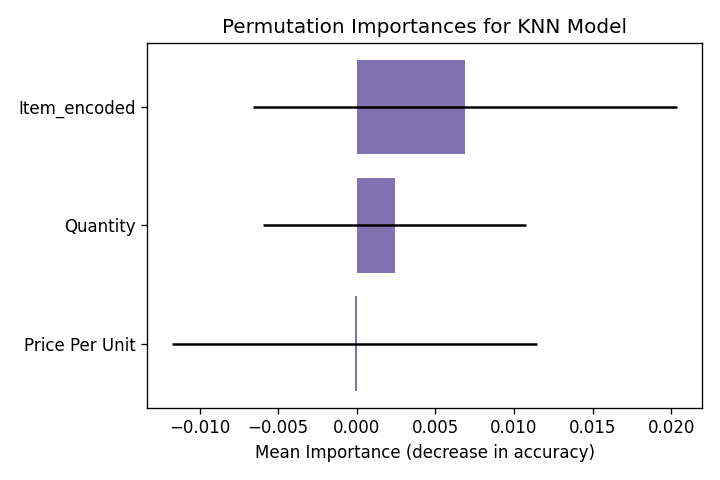

In [ ]:
plt.figure(figsize=(6,4))
plt.barh(perm_df['feature'], perm_df['importance_mean'], xerr=perm_df['importance_std'], color='#8172B2')
plt.xlabel('Mean Importance (decrease in accuracy)')
plt.title('Permutation Importances for KNN Model')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 10. Total quantity sold per item

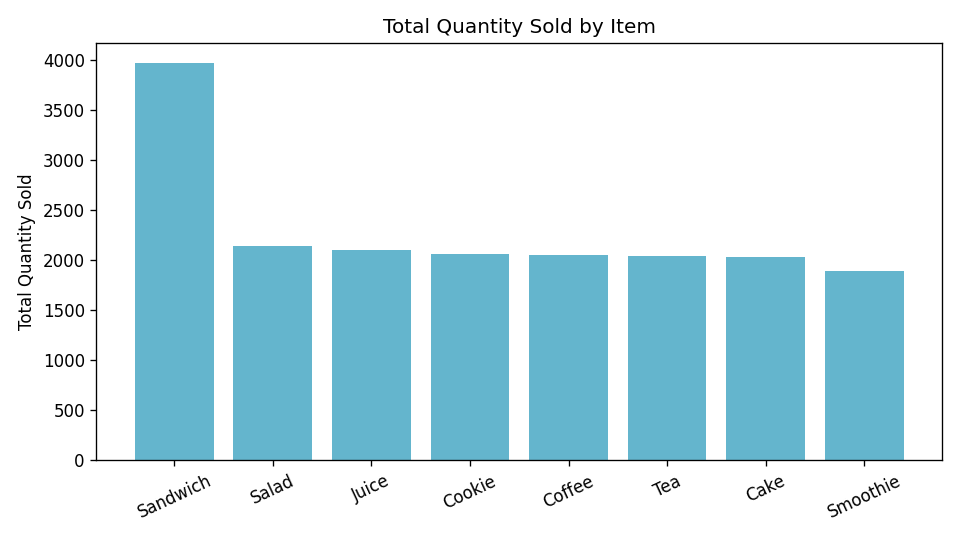

Sandwich    3976.0
Salad       2143.0
Juice       2101.0
Cookie      2066.0
Coffee      2057.0
Tea         2041.0
Cake        2038.0
Smoothie    1893.0

In [ ]:
qty_by_item = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4.5))
plt.bar(qty_by_item.index, qty_by_item.values, color='#64B5CD')
plt.ylabel('Total Quantity Sold'); plt.title('Total Quantity Sold by Item')
plt.xticks(rotation=25); plt.tight_layout(); plt.show()
qty_by_item

## Notes
- **Target**: `Location` (In-store vs Takeaway) - the only column in this dataset with exactly two classes, which matches a single accuracy/recall pair per model.
- **Google Sheets cell (`sheets.InteractiveSheet`)**: this only works inside Google Colab and only exports a DataFrame to a linked Google Sheet - it needs your Google credentials for that reason. It is **not required** for the analysis; skip it (or remove it) when running outside Colab / for a GitHub upload.
- **`step_artifacts`**: not a real requirement for this pipeline - it isn't a standard scikit-learn/pandas object. It's not needed to fully evaluate this dataset.
- All numbers above come from a single fixed `random_state=42` 80/20 split. Re-running with a different split/seed will shift the exact percentages slightly, though the ranking (Decision Tree best accuracy, KNN best recall) is stable across seeds since these features have very weak signal for this target (see the low SelectKBest and permutation-importance scores).